# 02 · KPIs, products and regions

Actual Superstore sample data, not simulated outputs. Run cells from top to bottom. Dollar amounts are USD.


In [1]:
from pathlib import Path
import sys
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'src/project.py').exists()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from inside the extracted project folder.')
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.project import load, summarize, save_table, chart
pd.set_option('display.max_columns',30)
pd.set_option('display.width',160)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize':(10,5),'axes.spines.top':False,'axes.spines.right':False})

## Definitions
Sales = sum of the source Sales column (treated as sales after discount). Profit = sum of source Profit. Margin = total Profit / total Sales, never the mean of line margins. AOV = total Sales / distinct orders. Orders per category overlap and must not be added across categories.

Sales                 2297200.86
Profit                 286397.02
Orders                   5009.00
Customers                 793.00
Units                   37873.00
Margin_pct                 12.47
AOV                       458.61
Loss_line_rate_pct         18.72
dtype: float64
                     Sales     Profit  Units  Orders  Lines  Margin_pct
Category                                                               
Technology       836154.03  145454.95   6939    1544   1847       17.40
Furniture        741999.80   18451.27   8028    1764   2121        2.49
Office Supplies  719047.03  122490.80  22906    3742   6026       17.04


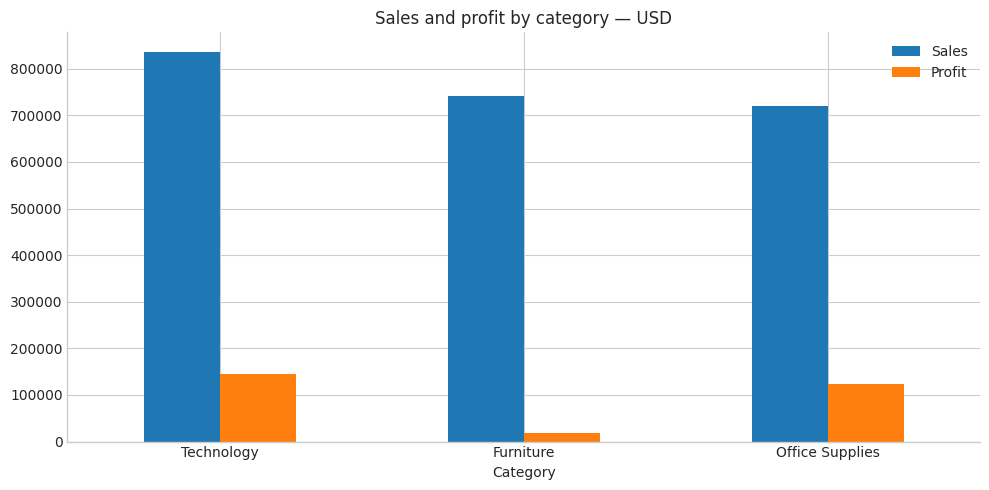

In [2]:
df=load()
kpis=pd.Series({'Sales':df.Sales.sum(),'Profit':df.Profit.sum(),'Orders':df['Order ID'].nunique(),'Customers':df['Customer ID'].nunique(),'Units':df.Quantity.sum(),'Margin_pct':100*df.Profit.sum()/df.Sales.sum(),'AOV':df.Sales.sum()/df['Order ID'].nunique(),'Loss_line_rate_pct':100*df['Loss Flag'].mean()})
print(kpis.round(2));save_table(kpis.to_frame('Value'),'kpis')
category=summarize(df,'Category');print(category.round(2));save_table(category,'category')
category[['Sales','Profit']].plot.bar(title='Sales and profit by category — USD',rot=0);chart('category')

                  Sales    Profit  Units  Orders  Lines  Margin_pct
Sub-Category                                                       
Tables        206965.53 -17725.48   1241     307    319       -8.56
Bookcases     114880.00  -3472.56    868     224    228       -3.02
Supplies       46673.54  -1189.10    647     187    190       -2.55
Fasteners       3024.28    949.52    914     215    217       31.40
Machines      189238.63   3384.76    440     112    115        1.79
Labels         12486.31   5546.25   1400     346    364       44.42
Art            27118.79   6527.79   3000     731    796       24.07
Envelopes      16476.40   6964.18    906     249    254       42.27
Furnishings    91705.16  13059.14   3563     877    957       14.24
Appliances    107532.16  18138.01   1729     451    466       16.87
Storage       223843.61  21278.83   3158     777    846        9.51
Chairs        328449.10  26590.17   2356     576    617        8.10
Binders       203412.73  30221.76   5974    1316

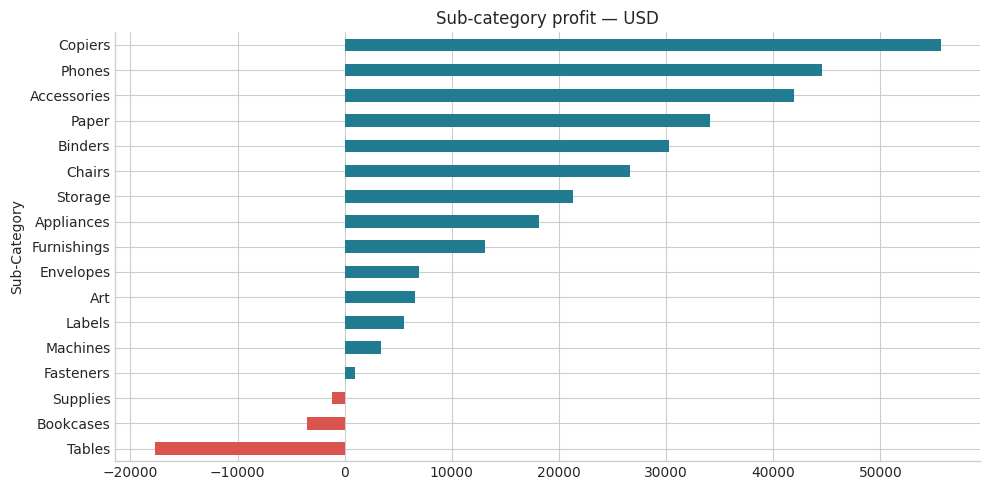

In [3]:
sub=summarize(df,'Sub-Category').sort_values('Profit')
print(sub.round(2));save_table(sub,'subcategory')
sub.Profit.plot.barh(color=np.where(sub.Profit<0,'#d9534f','#217b91'),title='Sub-category profit — USD');chart('subcategory_profit')
products=summarize(df,['Product ID','Product Name'])
print('Top products by sales:');print(products.head(10).round(2))
save_table(products,'products')

Product ID can map to different product names in sample data. Group by ID and name here; later exports create a surrogate product key for that combination rather than silently dropping names.

             Sales     Profit  Units  Orders  Lines  Margin_pct
Region                                                         
West     725457.82  108418.45  12266    1611   3203       14.94
East     678781.24   91522.78  10618    1401   2848       13.48
Central  501239.89   39706.36   8780    1175   2323        7.92
South    391721.90   46749.43   6209     822   1620       11.93
                    Sales    Profit  Units  Orders  Lines  Margin_pct
State                                                                
Texas           170188.05 -25729.36   3724     487    985      -15.12
Ohio             78258.14 -16971.38   1759     236    469      -21.69
Pennsylvania    116511.91 -15559.96   2153     288    587      -13.35
Illinois         80166.10 -12607.89   1845     276    492      -15.73
North Carolina   55603.16  -7490.91    983     136    249      -13.47
Colorado         32108.12  -6527.86    693      79    182      -20.33
Tennessee        30661.87  -5341.69    681      91    18

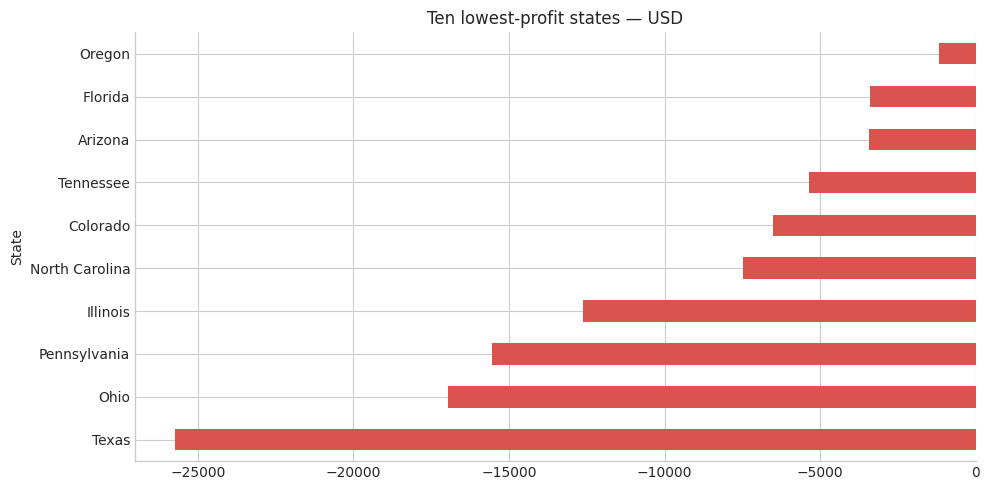

In [4]:
region=summarize(df,'Region');states=summarize(df,'State').sort_values('Profit')
segment=summarize(df,'Segment')
for name,table in [('region',region),('states',states),('segment',segment)]:save_table(table,name)
print(region.round(2));print(states.head(10).round(2));print(segment.round(2))
states.head(10).Profit.plot.barh(title='Ten lowest-profit states — USD',color='#d9534f');chart('state_profit')
negative=df.loc[df.Profit<0,'Profit'].sum()
positive=df.loc[df.Profit>=0,'Profit'].sum()
assert np.isclose(positive+negative,df.Profit.sum())
print(f'Profitable-line contribution: ${positive:,.2f}; loss-line contribution: ${negative:,.2f}')

## Decision use
Prioritize sub-categories and states with large absolute losses, then inspect their product and discount mix. High sales alone does not justify expansion; assess margin, demand, and costs before allocating more investment.